# Spectral gaps


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_DIR = Path("..").resolve()
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
CLUSTERFACTORY_DIR = Path.home() / "clusterfactory"
if CLUSTERFACTORY_DIR.exists() and str(CLUSTERFACTORY_DIR) not in sys.path:
    sys.path.insert(0, str(CLUSTERFACTORY_DIR))

from clusterfactory.experimental import slurm_map
from clusterfactory.slurm import SlurmConfig
from hierachical import HClusters
from sample import SampleProcessor

PROJECT_DIR = Path("/home/zw395/project_pi_ag245/zw395")
SCRATCH_DIR = Path("/home/zw395/scratch_pi_ag245/zw395")

PRECINCT_FN = PROJECT_DIR / "gm_dataset/graph_json/ct.json"
PROCESSED_ROOT = PROJECT_DIR / "processed"
OUTPUT_DIR = Path("output/ct_spectral")
RUN_DIR = SCRATCH_DIR / "gmstrat_ct_spectral_K50_Wref1000_Wtarget2000"
VOCAB_DIR = RUN_DIR / "reference_vocabulary"
TRANSFER_DIR = RUN_DIR / "transfer"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)
VOCAB_DIR.mkdir(parents=True, exist_ok=True)
TRANSFER_DIR.mkdir(parents=True, exist_ok=True)

NUM_DISTRICTS = 5
NUM_LETTERS = 50
NUM_PLANS = 50_000
REFERENCE_WORD_DEGREE = 1_000
TARGET_WORD_DEGREE = 2_000
TARGET_WORD_COUNTS = [50, 100, 200]
ETA_GRID = np.round(np.arange(0.4, 1.0, 0.01), 2)
TEMPERATURES = [0, 10, 20]
KC_CONVERGENCE = 0.01
KC_MAX_ITER = 50

plt.rcParams["font.size"] = 14

In [2]:
CALIBRATED_DISTRIBUTIONS = pd.DataFrame([
    (0.0, 0.000, "g00i00"),
    (0.1, 0.028, "g01i0028"),
    (0.2, 0.058, "g02i0058"),
    (0.3, 0.093, "g03i0093"),
    (0.4, 0.131, "g04i0131"),
    (0.5, 0.170, "g05i017"),
    (0.6, 0.213, "g06i0213"),
    (0.7, 0.258, "g07i0258"),
    (0.8, 0.307, "g08i0307"),
    (0.9, 0.357, "g09i0357"),
    (1.0, 0.410, "g10i041"),
], columns=["gamma", "iso", "code"])

def seeds_for_gamma(gamma):
    return {"A": 260508, "B": 260509} if float(gamma) == 0.0 else {"A": 250510, "B": 250511}

def processed_dir(seed, code):
    return PROCESSED_ROOT / f"ct_yale_seed{int(seed)}_{code}_calibrated_10Mburnin_50k"

sample_rows = []
for row in CALIBRATED_DISTRIBUTIONS.itertuples(index=False):
    for seed_label, seed in seeds_for_gamma(row.gamma).items():
        sample_rows.append({
            "gamma": row.gamma,
            "iso": row.iso,
            "code": row.code,
            "seed_label": seed_label,
            "seed": seed,
            "processed_dir": processed_dir(seed, row.code),
        })

sample_catalog = pd.DataFrame(sample_rows)
sample_catalog

,gamma,iso,code,seed_label,seed,processed_dir
0,0.0,0.000,g00i00,A,260508,/home/zw395/project_pi_ag245/zw395/processed/c...
1,0.0,0.000,g00i00,B,260509,/home/zw395/project_pi_ag245/zw395/processed/c...
2,0.1,0.028,g01i0028,A,250510,/home/zw395/project_pi_ag245/zw395/processed/c...
3,0.1,0.028,g01i0028,B,250511,/home/zw395/project_pi_ag245/zw395/processed/c...
4,0.2,0.058,g02i0058,A,250510,/home/zw395/project_pi_ag245/zw395/processed/c...
5,0.2,0.058,g02i0058,B,250511,/home/zw395/project_pi_ag245/zw395/processed/c...
6,0.3,0.093,g03i0093,A,250510,/home/zw395/project_pi_ag245/zw395/processed/c...
7,0.3,0.093,g03i0093,B,250511,/home/zw395/project_pi_ag245/zw395/processed/c...
8,0.4,0.131,g04i0131,A,250510,/home/zw395/project_pi_ag245/zw395/processed/c...
9,0.4,0.131,g04i0131,B,250511,/home/zw395/project_pi_ag245/zw395/processed/c...


In [6]:
if not PRECINCT_FN.exists():
    raise FileNotFoundError(PRECINCT_FN)

missing_targets = [path for path in sample_catalog.processed_dir if not path.exists()]
if missing_targets:
    raise FileNotFoundError(
        "Missing calibrated processed directories:\n" + "\n".join(map(str, missing_targets))
    )

reference_row = sample_catalog.query("gamma == 0 and seed_label == 'A'").iloc[0]
REFERENCE_PROCESSED_DIR = Path(reference_row.processed_dir)

sp_ref = SampleProcessor(PRECINCT_FN, REFERENCE_PROCESSED_DIR)
sp_ref.load_processed()

In [8]:
CALIBRATED_DISTRIBUTIONS

,gamma,iso,code
0,0.0,0.000,g00i00
1,0.1,0.028,g01i0028
2,0.2,0.058,g02i0058
3,0.3,0.093,g03i0093
4,0.4,0.131,g04i0131
5,0.5,0.170,g05i017
6,0.6,0.213,g06i0213
7,0.7,0.258,g07i0258
8,0.8,0.307,g08i0307
9,0.9,0.357,g09i0357


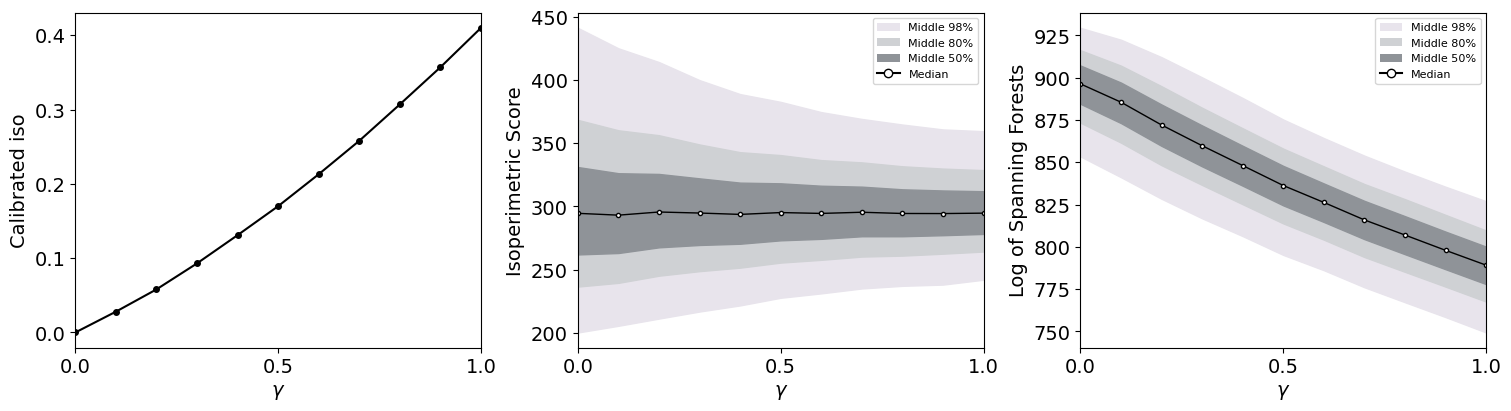

In [9]:
import gzip
import json

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

CALIBRATED_SAMPLE_ROOT = (
    SCRATCH_DIR
    / "gm"
    / "calibrated_samples_ct"
)

BURN_IN_STEP = 10_000_000
NUM_SAMPLES = 50_000


def read_calibration_sample(path):
    iso_scores = []
    log_forests = []

    with gzip.open(
        path,
        "rt",
        encoding="utf-8",
    ) as file:
        for line_number, line in enumerate(file):
            if line_number < 3:
                continue

            record = json.loads(line)

            step = int(
                str(record["name"])
                .removeprefix("step")
            )

            if step <= BURN_IN_STEP:
                continue

            data = record["data"]

            iso_scores.append(
                sum(
                    data[
                        "get_isoperimetric_scores"
                    ]
                )
            )

            if "get_log_spanning_forests" in data:
                log_forests.append(
                    data[
                        "get_log_spanning_forests"
                    ]
                )
            else:
                log_forests.append(
                    sum(
                        data[
                            "get_log_spanning_trees"
                        ]
                    )
                )

            if len(iso_scores) == NUM_SAMPLES:
                break

    return (
        np.asarray(iso_scores),
        np.asarray(log_forests),
    )


gammas = (
    CALIBRATED_DISTRIBUTIONS
    .gamma
    .to_numpy(dtype=float)
)

isos = (
    CALIBRATED_DISTRIBUTIONS
    .iso
    .to_numpy(dtype=float)
)

iso_samples = []
forest_samples = []

for gamma, iso in zip(gammas, isos):
    seed = (
        260508
        if gamma == 0
        else 250510
    )

    sample_dir = (
        CALIBRATED_SAMPLE_ROOT
        / (
            f"gamma{gamma:.1f}_"
            f"iso{iso:.3f}_"
            f"seed{seed}"
        )
    )

    sample_path = next(
        sample_dir.glob("*.jsonl.gz")
    )

    iso_values, forest_values = (
        read_calibration_sample(
            sample_path
        )
    )

    iso_samples.append(iso_values)
    forest_samples.append(forest_values)

quantiles = [
    0.01,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.99,
]

iso_bands = np.quantile(
    np.stack(iso_samples),
    quantiles,
    axis=1,
)

forest_bands = np.quantile(
    np.stack(forest_samples),
    quantiles,
    axis=1,
)


def plot_bands(
    ax,
    x,
    bands,
    ylabel,
):
    colors = [
        "#e8e4ec",
        "#cfd1d4",
        "#8f9398",
    ]

    ax.fill_between(
        x,
        bands[0],
        bands[6],
        color=colors[0],
    )

    ax.fill_between(
        x,
        bands[1],
        bands[5],
        color=colors[1],
    )

    ax.fill_between(
        x,
        bands[2],
        bands[4],
        color=colors[2],
    )

    ax.plot(
        x,
        bands[3],
        "-o",
        color="black",
        markersize=3,
        linewidth=1,
        markerfacecolor="white",
    )

    ax.set_xlabel(
        r"$\gamma$"
    )
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, 1)
    ax.set_xticks([0, 0.5, 1])

    ax.legend(
        handles=[
            Patch(
                facecolor=colors[0],
                label="Middle 98%",
            ),
            Patch(
                facecolor=colors[1],
                label="Middle 80%",
            ),
            Patch(
                facecolor=colors[2],
                label="Middle 50%",
            ),
            Line2D(
                [0],
                [0],
                color="black",
                marker="o",
                markerfacecolor="white",
                label="Median",
            ),
        ],
        fontsize=8,
    )


fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4),
    constrained_layout=True,
)

axes[0].plot(
    gammas,
    isos,
    "-o",
    color="black",
    markersize=4,
)

axes[0].set_xlabel(
    r"$\gamma$"
)
axes[0].set_ylabel("Calibrated iso")
axes[0].set_xlim(0, 1)
axes[0].set_xticks([0, 0.5, 1])

plot_bands(
    axes[1],
    gammas,
    iso_bands,
    "Isoperimetric Score",
)

plot_bands(
    axes[2],
    gammas,
    forest_bands,
    "Log of Spanning Forests",
)

fig.savefig(
    OUTPUT_DIR / "iso_calibration.png",
    dpi=400,
    bbox_inches="tight",
)

plt.show()

In [10]:
hc_ref = HClusters(sp_ref)
hc_ref.update_clusters(NUM_LETTERS)

hc_ref.kcentroids(
    convergence_thres=KC_CONVERGENCE,
    max_iter=KC_MAX_ITER,
    verbose=True,
)

centroids = [np.asarray(centroid, dtype=np.int32) for centroid in hc_ref.centroids]

  0%|          | 0/50 [00:00<?, ?it/s]

epoch 0: rel_improvement = 0.08776968754194804
epoch 1: rel_improvement = 0.021142073611634702
epoch 2: rel_improvement = 0.014525087504699562


In [11]:
RUN_DIR = (
    SCRATCH_DIR
    / "gmstrat_ct_numerics2_K50_Wref1000_Wtarget2000"
)

VOCAB_DIR = (
    RUN_DIR
    / "reference_vocabulary"
)

TRANSFER_DIR = (
    RUN_DIR
    / "transfer"
)

TRANSFER_ETAS = [
    0.59,
    0.63,
    0.70,
]

fixed_words_by_eta = {
    eta: pd.read_feather(
        VOCAB_DIR
        / f"fixed_words_eta_{eta:.2f}.feather"
    )
    for eta in TRANSFER_ETAS
}

reference_word_sets = pd.DataFrame([
    {
        "eta": eta,
        "num_words": len(
            fixed_words_by_eta[eta]
        ),
        "path": str(
            VOCAB_DIR
            / f"fixed_words_eta_{eta:.2f}.feather"
        ),
    }
    for eta in TRANSFER_ETAS
])

reference_word_sets

,eta,num_words,path
0,0.59,188,/home/zw395/scratch_pi_ag245/zw395/gmstrat_ct_...
1,0.63,103,/home/zw395/scratch_pi_ag245/zw395/gmstrat_ct_...
2,0.70,50,/home/zw395/scratch_pi_ag245/zw395/gmstrat_ct_...


In [12]:
from scipy import sparse

from cover import greedy_two_stage_cover

TRANSFER_ETAS = [
    0.59,
    0.63,
    0.70,
]


def compute_fixed_word_sets():
    chunk_paths = sorted(
        (
            VOCAB_DIR
            / "chunks"
        ).glob("plans_*.npz")
    )

    unique_codes = []
    tau = 0.0

    for path in chunk_paths:
        with np.load(
            path,
            allow_pickle=False,
        ) as chunk:
            unique_codes.append(
                np.unique(
                    chunk["word_code"]
                )
            )

            tau = max(
                tau,
                float(
                    chunk[
                        "min_distance"
                    ].max()
                ),
            )

    catalog = np.unique(
        np.concatenate(
            unique_codes
        )
    )

    row_parts = []
    col_parts = []
    distance_parts = []

    for path in chunk_paths:
        with np.load(
            path,
            allow_pickle=False,
        ) as chunk:
            eligible = (
                chunk["distance"]
                <= tau
            )

            row_parts.append(
                chunk["plan_uid"][
                    eligible
                ]
            )

            col_parts.append(
                np.searchsorted(
                    catalog,
                    chunk["word_code"][
                        eligible
                    ],
                ).astype(np.int32)
            )

            distance_parts.append(
                chunk["distance"][
                    eligible
                ]
            )

    rows = np.concatenate(
        row_parts
    )

    cols = np.concatenate(
        col_parts
    )

    distances = np.concatenate(
        distance_parts
    )

    num_plans = len(
        sp_ref.df_distributions
    )

    broad_covermat = (
        sparse.coo_matrix(
            (
                np.ones(
                    len(rows),
                    dtype=bool,
                ),
                (rows, cols),
            ),
            shape=(
                num_plans,
                len(catalog),
            ),
        )
        .tocsc()
    )

    np.save(
        VOCAB_DIR
        / "word_catalog.npy",
        catalog,
        allow_pickle=False,
    )

    total_population = float(
        np.asarray(
            sp_ref.population
        ).sum()
    )

    def decode_word(code):
        word = np.empty(
            NUM_DISTRICTS,
            dtype=np.int32,
        )

        value = int(code)

        for position in range(
            NUM_DISTRICTS - 1,
            -1,
            -1,
        ):
            word[position] = (
                value % NUM_LETTERS
            )
            value //= NUM_LETTERS

        return ".".join(
            str(int(letter))
            for letter in word
        )

    summary_rows = []

    for eta in TRANSFER_ETAS:
        core_eligible = (
            distances
            <= eta * total_population
        )

        core_covermat = (
            sparse.coo_matrix(
                (
                    np.ones(
                        core_eligible.sum(),
                        dtype=bool,
                    ),
                    (
                        rows[
                            core_eligible
                        ],
                        cols[
                            core_eligible
                        ],
                    ),
                ),
                shape=broad_covermat.shape,
            )
            .tocsc()
        )

        result = (
            greedy_two_stage_cover(
                core_covermat,
                broad_covermat,
            )
        )

        selected_codes = catalog[
            result.selected_sets
        ]

        np.save(
            VOCAB_DIR
            / (
                f"eta_{eta:.2f}_"
                "selected_codes.npy"
            ),
            selected_codes,
            allow_pickle=False,
        )

        fixed_words = pd.DataFrame({
            "word_uid": (
                np.searchsorted(
                    catalog,
                    selected_codes,
                )
                .astype(np.int32)
            ),
            "word_str": [
                decode_word(code)
                for code
                in selected_codes
            ],
        })

        fixed_words = (
            fixed_words
            .sort_values("word_uid")
            .reset_index(drop=True)
        )

        fixed_words.to_feather(
            VOCAB_DIR
            / (
                f"fixed_words_eta_"
                f"{eta:.2f}.feather"
            )
        )

        summary_rows.append({
            "eta": eta,
            "tau": tau,
            "core_words": len(
                result.core_sets
            ),
            "repair_words": len(
                result.tail_sets
            ),
            "selected_words": len(
                result.selected_sets
            ),
            "core_uncovered_plans": len(
                result.core_uncovered_nodes
            ),
            "final_uncovered_plans": len(
                result.tail_uncovered_nodes
            ),
        })

    summary = pd.DataFrame(
        summary_rows
    )

    summary.to_csv(
        VOCAB_DIR
        / "fixed_eta_summary.csv",
        index=False,
    )

    return summary


# fixed_eta_summary = compute_fixed_word_sets()

In [13]:
selected_codes_by_eta = {
    eta: np.load(
        VOCAB_DIR
        / (
            f"eta_{eta:.2f}_"
            "selected_codes.npy"
        ),
        allow_pickle=False,
    )
    for eta in TRANSFER_ETAS
}

fixed_words_by_eta = {
    eta: pd.read_feather(
        VOCAB_DIR
        / (
            f"fixed_words_eta_"
            f"{eta:.2f}.feather"
        )
    )
    for eta in TRANSFER_ETAS
}

eta_summary = (
    pd.read_csv(
        VOCAB_DIR
        / "eta_sweep.csv"
    )
)

eta_summary = (
    eta_summary[
        eta_summary.eta.round(2).isin(
            TRANSFER_ETAS
        )
    ]
    .sort_values("eta")
    .reset_index(drop=True)
)

eta_summary

,eta,tau,core_words,repair_words,selected_words,core_uncovered_plans,final_uncovered_plans
0,0.59,2616356.0,186,2,188,78,0
1,0.63,2616356.0,99,4,103,17,0
2,0.70,2616356.0,48,2,50,2,0


In [14]:
from types import SimpleNamespace

from word import compute_fixed_word_stats

TARGET_WORD_DEGREE = 2000
TEMPERATURES = [0, 10, 20]

reference_clusters = SimpleNamespace(
    centroids=centroids
)


def compute_all_transfers():
    all_summaries = []

    for eta in TRANSFER_ETAS:
        fixed_words = (
            fixed_words_by_eta[eta]
        )

        for target in sample_catalog.itertuples(
            index=False
        ):
            sp_target = SampleProcessor(
                PRECINCT_FN,
                Path(
                    target.processed_dir
                ),
            )

            sp_target.load_processed()

            stats = compute_fixed_word_stats(
                sp_target,
                reference_clusters,
                fixed_words,
                word_degree=TARGET_WORD_DEGREE,
                temperatures=TEMPERATURES,
                total_population=float(
                    np.asarray(
                        sp_target.population
                    ).sum()
                ),
                verbose=True,
                centroid_norm="l1",
            )

            rows = []

            for temperature in TEMPERATURES:
                temperature = float(
                    temperature
                )

                stationary = (
                    stats.stationary[
                        temperature
                    ]
                )

                flux = (
                    stats.flux[
                        temperature
                    ]
                )

                active = stationary > 0

                artifact_path = (
                    TRANSFER_DIR
                    / (
                        f"eta_{eta:.2f}_"
                        f"gamma_{target.gamma:.1f}_"
                        f"{target.seed_label}_"
                        f"seed_{target.seed}_"
                        f"T_{temperature:g}.npz"
                    )
                )

                np.savez_compressed(
                    artifact_path,
                    eta=np.asarray(eta),
                    gamma=np.asarray(
                        target.gamma
                    ),
                    iso=np.asarray(
                        target.iso
                    ),
                    seed_label=np.asarray(
                        target.seed_label,
                        dtype=str,
                    ),
                    seed=np.asarray(
                        target.seed
                    ),
                    temperature=np.asarray(
                        temperature
                    ),
                    word_uids=(
                        stats.word_uids
                    ),
                    word_strs=(
                        stats.word_strs
                    ),
                    active_word_uids=(
                        stats.word_uids[
                            active
                        ]
                    ),
                    stationary=stationary,
                    flux=flux,
                    covered_mass=np.asarray(
                        stats.covered_mass
                    ),
                )

                rows.append({
                    "eta": eta,
                    "gamma": target.gamma,
                    "iso": target.iso,
                    "seed_label": (
                        target.seed_label
                    ),
                    "seed": target.seed,
                    "temperature": temperature,
                    "num_words": len(
                        stats.word_uids
                    ),
                    "active_words": int(
                        active.sum()
                    ),
                    "covered_plans": (
                        stats.covered_plans
                    ),
                    "covered_mass": (
                        stats.covered_mass
                    ),
                    "artifact_path": str(
                        artifact_path
                    ),
                })

            summary = pd.DataFrame(
                rows
            )

            summary_path = (
                TRANSFER_DIR
                / (
                    f"summary_eta_{eta:.2f}_"
                    f"gamma_{target.gamma:.1f}_"
                    f"{target.seed_label}_"
                    f"seed_{target.seed}.csv"
                )
            )

            summary.to_csv(
                summary_path,
                index=False,
            )

            all_summaries.append(
                summary
            )

    return (
        pd.concat(
            all_summaries,
            ignore_index=True,
        )
        .sort_values(
            [
                "eta",
                "temperature",
                "seed_label",
                "gamma",
            ]
        )
        .reset_index(drop=True)
    )


# computed_transfer_df = compute_all_transfers()

In [15]:
from tqdm.auto import tqdm

transfer_df = (
    pd.concat(
        [
            pd.read_csv(path)
            for path
            in TRANSFER_DIR.glob(
                "summary_eta_*_gamma_*_seed_*.csv"
            )
        ],
        ignore_index=True,
    )
)

transfer_df = (
    transfer_df[
        transfer_df.eta
        .round(2)
        .isin(TRANSFER_ETAS)
    ]
    .sort_values(
        [
            "eta",
            "temperature",
            "seed_label",
            "gamma",
        ]
    )
    .reset_index(drop=True)
)

transfer_results = {}

for row in tqdm(
    transfer_df.itertuples(),
    total=len(transfer_df),
):
    with np.load(
        row.artifact_path,
        allow_pickle=False,
    ) as artifact:
        key = (
            round(
                float(row.eta),
                2,
            ),
            float(row.gamma),
            str(row.seed_label),
            float(row.temperature),
        )

        transfer_results[key] = {
            "stationary": (
                artifact[
                    "stationary"
                ].copy()
            ),
            "flux": (
                artifact[
                    "flux"
                ].copy()
            ),
            "word_uids": (
                artifact[
                    "word_uids"
                ].copy()
            ),
            "word_strs": (
                artifact[
                    "word_strs"
                ].copy()
            ),
            "active_word_uids": (
                artifact[
                    "active_word_uids"
                ].copy()
            ),
            "covered_mass": float(
                artifact[
                    "covered_mass"
                ]
            ),
        }

transfer_df

  0%|          | 0/198 [00:00<?, ?it/s]

,eta,gamma,iso,seed_label,seed,temperature,num_words,active_words,covered_plans,covered_mass,artifact_path
0,0.59,0.0,0.000,A,260508,0.0,188,188,50000,1.00000,/home/zw395/scratch_pi_ag245/zw395/gmstrat_ct_...
1,0.59,0.1,0.028,A,250510,0.0,188,188,50000,1.00000,/home/zw395/scratch_pi_ag245/zw395/gmstrat_ct_...
2,0.59,0.2,0.058,A,250510,0.0,188,188,50000,1.00000,/home/zw395/scratch_pi_ag245/zw395/gmstrat_ct_...
3,0.59,0.3,0.093,A,250510,0.0,188,188,50000,1.00000,/home/zw395/scratch_pi_ag245/zw395/gmstrat_ct_...
4,0.59,0.4,0.131,A,250510,0.0,188,188,50000,1.00000,/home/zw395/scratch_pi_ag245/zw395/gmstrat_ct_...
...,...,...,...,...,...,...,...,...,...,...,...
193,0.70,0.6,0.213,B,250511,20.0,50,50,49977,0.99954,/home/zw395/scratch_pi_ag245/zw395/gmstrat_ct_...
194,0.70,0.7,0.258,B,250511,20.0,50,50,49990,0.99980,/home/zw395/scratch_pi_ag245/zw395/gmstrat_ct_...
195,0.70,0.8,0.307,B,250511,20.0,50,50,49988,0.99976,/home/zw395/scratch_pi_ag245/zw395/gmstrat_ct_...
196,0.70,0.9,0.357,B,250511,20.0,50,49,49977,0.99954,/home/zw395/scratch_pi_ag245/zw395/gmstrat_ct_...


In [16]:
from tqdm.auto import tqdm

transfer_df = pd.concat(
    [
        pd.read_csv(path)
        for path in TRANSFER_DIR.glob(
            "summary_eta_*_gamma_*_seed_*.csv"
        )
    ],
    ignore_index=True,
)

transfer_df = (
    transfer_df[
        transfer_df.eta
        .round(2)
        .isin(TRANSFER_ETAS)
    ]
    .sort_values(
        [
            "eta",
            "temperature",
            "seed_label",
            "gamma",
        ]
    )
    .reset_index(drop=True)
)

transfer_results = {}
spectral_results = []
coverage_rows = []

for row in tqdm(
    transfer_df.itertuples(),
    total=len(transfer_df),
):
    key = (
        round(float(row.eta), 2),
        float(row.gamma),
        str(row.seed_label),
        float(row.temperature),
    )

    with np.load(
        row.artifact_path,
        allow_pickle=False,
    ) as artifact:
        stationary = artifact[
            "stationary"
        ].copy()

        flux = artifact[
            "flux"
        ].copy()

        word_uids = artifact[
            "word_uids"
        ].copy()

        word_strs = artifact[
            "word_strs"
        ].copy()

        covered_mass = float(
            artifact[
                "covered_mass"
            ]
        )

    if np.any(stationary < 0):
        raise ValueError(
            f"Negative stationary weight for {key}"
        )

    if np.any(flux < 0):
        raise ValueError(
            f"Negative flux entry for {key}"
        )

    active = stationary > 0

    active_stationary = stationary[
        active
    ]

    active_flux = flux[
        np.ix_(active, active)
    ]

    active_word_uids = word_uids[
        active
    ]

    active_word_strs = word_strs[
        active
    ]

    row_sums = active_flux.sum(
        axis=1
    )

    if not np.allclose(
        row_sums,
        1.0,
        atol=1e-10,
    ):
        raise ValueError(
            f"Flux rows do not sum to one for {key}"
        )

    normalized_stationary = (
        active_stationary
        / active_stationary.sum()
    )

    transfer_results[key] = {
        "stationary": stationary,
        "flux": flux,
        "word_uids": word_uids,
        "word_strs": word_strs,
        "active_word_uids": (
            active_word_uids
        ),
        "covered_mass": covered_mass,
    }

    spectral_results.append({
        "eta": key[0],
        "gamma": key[1],
        "seed_label": key[2],
        "temperature": key[3],
        "word_uids": active_word_uids,
        "word_strs": active_word_strs,
        "stationary": (
            normalized_stationary
        ),
        "flux": active_flux,
    })

    coverage_rows.append({
        "eta": key[0],
        "gamma": key[1],
        "seed_label": key[2],
        "temperature": key[3],
        "covered_plans": int(
            row.covered_plans
        ),
        "covered_mass": covered_mass,
        "total_words": len(
            stationary
        ),
        "active_words": int(
            active.sum()
        ),
        "minimum_row_sum": float(
            row_sums.min()
        ),
        "maximum_row_sum": float(
            row_sums.max()
        ),
    })

coverage_report = (
    pd.DataFrame(coverage_rows)
    .sort_values(
        [
            "eta",
            "temperature",
            "seed_label",
            "gamma",
        ]
    )
    .reset_index(drop=True)
)

coverage_report

  0%|          | 0/198 [00:00<?, ?it/s]

,eta,gamma,seed_label,temperature,covered_plans,covered_mass,total_words,active_words,minimum_row_sum,maximum_row_sum
0,0.59,0.0,A,0.0,50000,1.00000,188,188,1.0,1.0
1,0.59,0.1,A,0.0,50000,1.00000,188,188,1.0,1.0
2,0.59,0.2,A,0.0,50000,1.00000,188,188,1.0,1.0
3,0.59,0.3,A,0.0,50000,1.00000,188,188,1.0,1.0
4,0.59,0.4,A,0.0,50000,1.00000,188,188,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...
193,0.70,0.6,B,20.0,49977,0.99954,50,50,1.0,1.0
194,0.70,0.7,B,20.0,49990,0.99980,50,50,1.0,1.0
195,0.70,0.8,B,20.0,49988,0.99976,50,50,1.0,1.0
196,0.70,0.9,B,20.0,49977,0.99954,50,49,1.0,1.0


  0%|          | 0/11 [00:00<?, ?it/s]

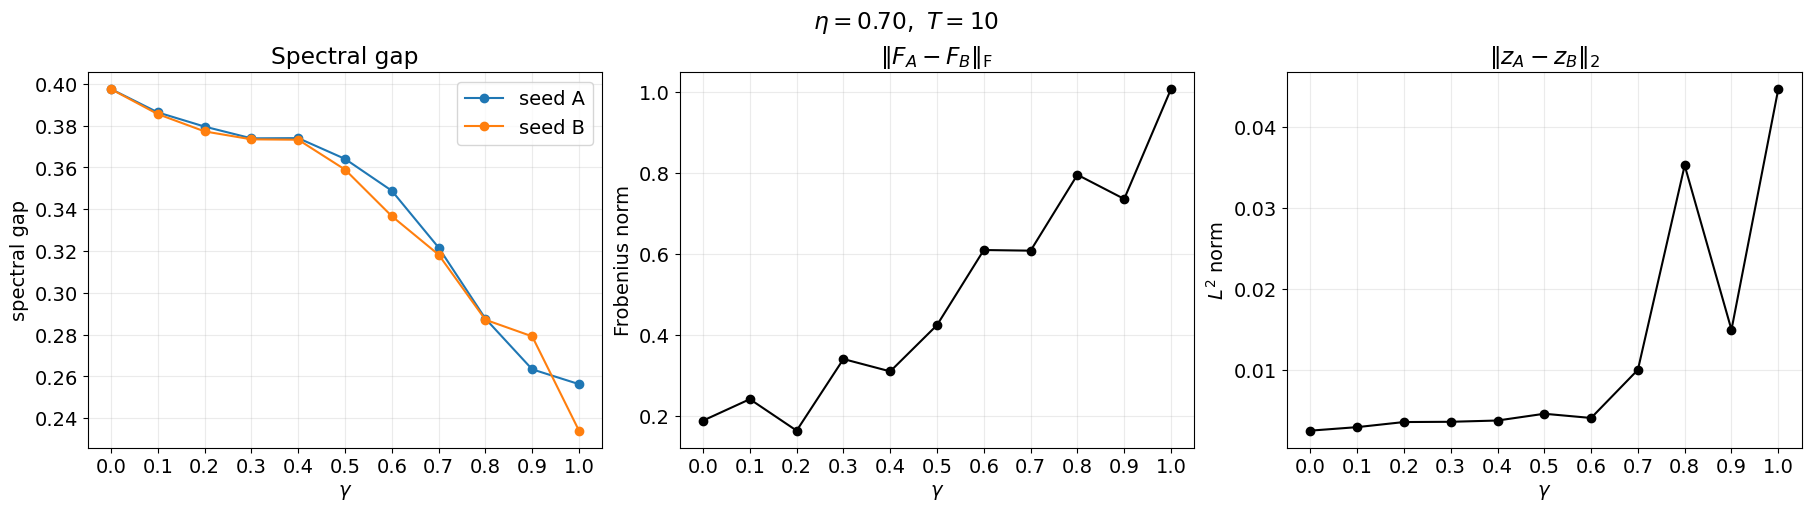

,eta,temperature,gamma,spectral_gap_seed_a,spectral_gap_seed_b,flux_frobenius,stationary_l2
0,0.7,10.0,0.0,0.397478,0.397444,0.189181,0.002534
1,0.7,10.0,0.1,0.386311,0.385494,0.241982,0.002966
2,0.7,10.0,0.2,0.379523,0.377221,0.164403,0.003595
3,0.7,10.0,0.3,0.373906,0.373427,0.340859,0.003626
4,0.7,10.0,0.4,0.374008,0.373246,0.310421,0.003783
5,0.7,10.0,0.5,0.364070,0.358966,0.424507,0.004618
6,0.7,10.0,0.6,0.348831,0.336673,0.609530,0.004099
7,0.7,10.0,0.7,0.321639,0.318252,0.607937,0.010044
8,0.7,10.0,0.8,0.287632,0.287096,0.794988,0.035265
9,0.7,10.0,0.9,0.263381,0.279154,0.735356,0.014982


In [17]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
from tqdm.auto import tqdm

ETA_TO_PLOT = 0.70
TEMPERATURE_TO_PLOT = 10

eta_key = round(
    float(ETA_TO_PLOT),
    2,
)

temperature_key = float(
    TEMPERATURE_TO_PLOT
)

selected_df = transfer_df[
    np.isclose(
        transfer_df.eta,
        eta_key,
    )
    & np.isclose(
        transfer_df.temperature,
        temperature_key,
    )
]

gammas = sorted(
    selected_df.gamma.unique()
)


def spectral_gap(result):
    active = (
        result["stationary"] > 0
    )

    transition = result["flux"][
        np.ix_(active, active)
    ].copy()

    transition /= transition.sum(
        axis=1,
        keepdims=True,
    )

    eigenvalues = np.sort(
        np.abs(
            np.linalg.eigvals(
                transition
            )
        )
    )[::-1]

    return float(
        1 - eigenvalues[1]
    )


spectral_a = []
spectral_b = []
flux_difference = []
stationary_difference = []
metric_rows = []

for gamma in tqdm(gammas):
    key_a = (
        eta_key,
        float(gamma),
        "A",
        temperature_key,
    )

    key_b = (
        eta_key,
        float(gamma),
        "B",
        temperature_key,
    )

    result_a = transfer_results[
        key_a
    ]

    result_b = transfer_results[
        key_b
    ]

    gap_a = spectral_gap(
        result_a
    )

    gap_b = spectral_gap(
        result_b
    )

    flux_norm = np.linalg.norm(
        result_a["flux"]
        - result_b["flux"],
        ord="fro",
    )

    stationary_a = (
        result_a["stationary"]
        .copy()
    )

    stationary_b = (
        result_b["stationary"]
        .copy()
    )

    stationary_a /= (
        stationary_a.sum()
    )

    stationary_b /= (
        stationary_b.sum()
    )

    stationary_norm = np.linalg.norm(
        stationary_a
        - stationary_b
    )

    spectral_a.append(
        gap_a
    )

    spectral_b.append(
        gap_b
    )

    flux_difference.append(
        flux_norm
    )

    stationary_difference.append(
        stationary_norm
    )

    metric_rows.append({
        "eta": eta_key,
        "temperature": (
            temperature_key
        ),
        "gamma": gamma,
        "spectral_gap_seed_a": (
            gap_a
        ),
        "spectral_gap_seed_b": (
            gap_b
        ),
        "flux_frobenius": (
            flux_norm
        ),
        "stationary_l2": (
            stationary_norm
        ),
    })

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    constrained_layout=True,
)

axes[0].plot(
    gammas,
    spectral_a,
    "-o",
    label="seed A",
)

axes[0].plot(
    gammas,
    spectral_b,
    "-o",
    label="seed B",
)

axes[0].set_title(
    "Spectral gap"
)

axes[0].set_ylabel(
    "spectral gap"
)

axes[0].legend()

axes[1].plot(
    gammas,
    flux_difference,
    "-o",
    color="black",
)

axes[1].set_title(
    r"$\|F_A-F_B\|_{\mathrm{F}}$"
)

axes[1].set_ylabel(
    "Frobenius norm"
)

axes[2].plot(
    gammas,
    stationary_difference,
    "-o",
    color="black",
)

axes[2].set_title(
    r"$\|z_A-z_B\|_2$"
)

axes[2].set_ylabel(
    r"$L^2$ norm"
)

for ax in axes:
    ax.set_xlabel(
        r"$\gamma$"
    )

    ax.set_xticks(
        gammas
    )

    ax.grid(
        alpha=0.25
    )

fig.suptitle(
    rf"$\eta={eta_key:.2f},"
    rf"\ T={temperature_key:g}$"
)

fig.savefig(
    OUTPUT_DIR
    / (
        f"ct_transfer_eta_"
        f"{eta_key:.2f}_"
        f"T_{temperature_key:g}.png"
    ),
    dpi=400,
    bbox_inches="tight",
)

plt.show()

transfer_metrics = pd.DataFrame(
    metric_rows
)

transfer_metrics.to_csv(
    OUTPUT_DIR
    / (
        f"ct_transfer_eta_"
        f"{eta_key:.2f}_"
        f"T_{temperature_key:g}.csv"
    ),
    index=False,
)

transfer_metrics

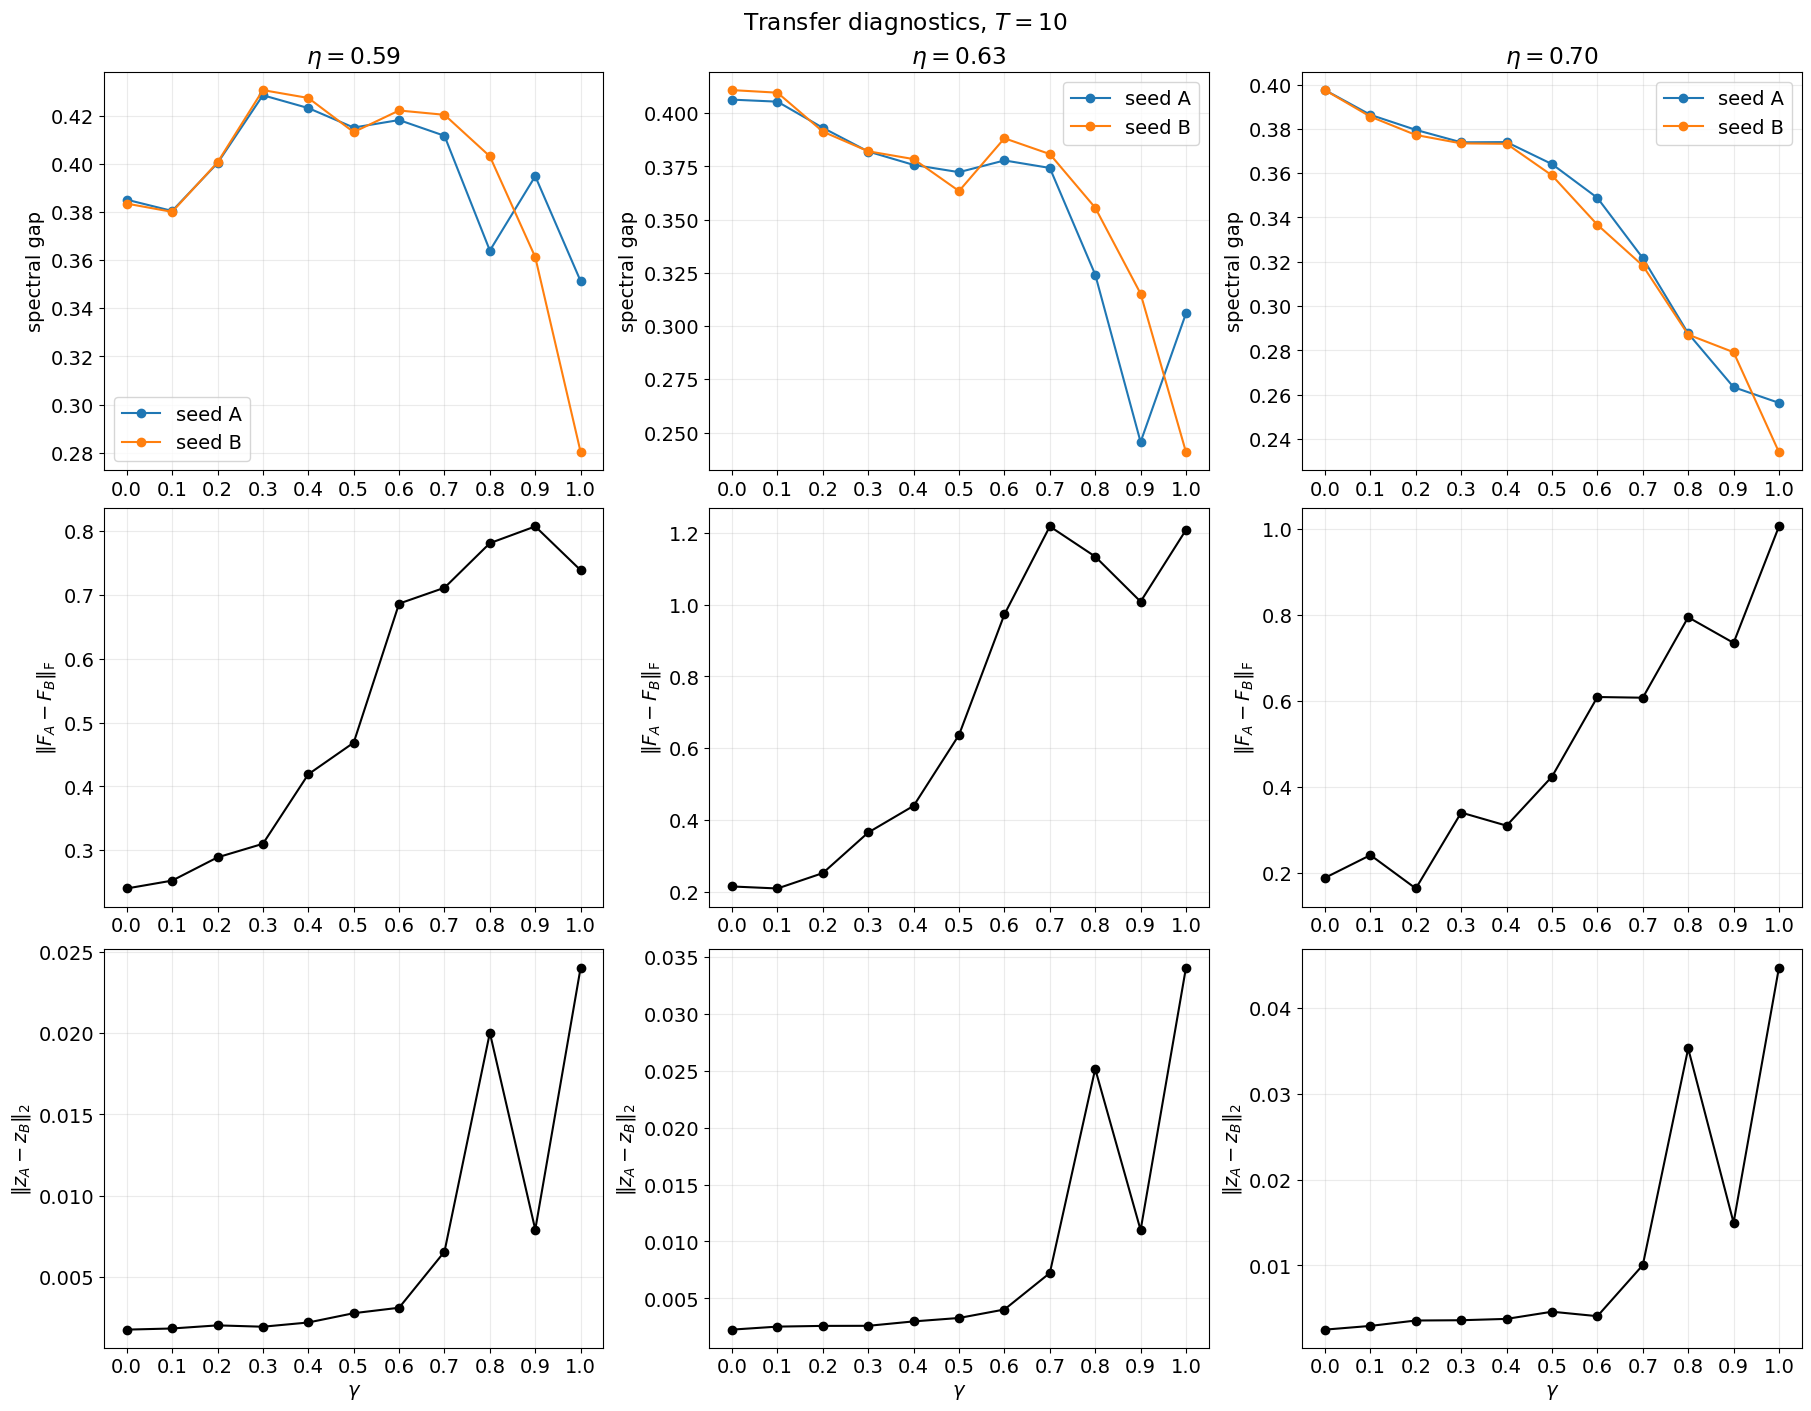

,eta,temperature,gamma,spectral_gap_seed_a,spectral_gap_seed_b,flux_frobenius,stationary_l2
0,0.59,10.0,0.0,0.385129,0.383503,0.240091,0.001736
1,0.59,10.0,0.1,0.380453,0.380071,0.252407,0.001805
2,0.59,10.0,0.2,0.400310,0.400621,0.288834,0.001997
3,0.59,10.0,0.3,0.428529,0.430666,0.310112,0.001915
4,0.59,10.0,0.4,0.423200,0.427399,0.419053,0.002175
5,0.59,10.0,0.5,0.415099,0.413218,0.468597,0.002748
6,0.59,10.0,0.6,0.418227,0.422194,0.686544,0.003084
7,0.59,10.0,0.7,0.411680,0.420404,0.711395,0.006538
8,0.59,10.0,0.8,0.363996,0.403147,0.781292,0.020030
9,0.59,10.0,0.9,0.394894,0.361264,0.807538,0.007902


In [18]:
ETAS_TO_PLOT = [
    0.59,
    0.63,
    0.70,
]

TEMPERATURE_TO_PLOT = 10.0


def spectral_gap(result):
    active = (
        result["stationary"] > 0
    )

    transition = result["flux"][
        np.ix_(active, active)
    ].copy()

    transition /= transition.sum(
        axis=1,
        keepdims=True,
    )

    eigenvalues = np.sort(
        np.abs(
            np.linalg.eigvals(
                transition
            )
        )
    )[::-1]

    return float(
        1 - eigenvalues[1]
    )


fig, axes = plt.subplots(
    3,
    3,
    figsize=(18, 14),
    constrained_layout=True,
)

all_metric_rows = []

for column, eta in enumerate(
    ETAS_TO_PLOT
):
    eta_key = round(
        float(eta),
        2,
    )

    selected_df = transfer_df[
        np.isclose(
            transfer_df.eta,
            eta_key,
        )
        & np.isclose(
            transfer_df.temperature,
            TEMPERATURE_TO_PLOT,
        )
    ]

    gammas = sorted(
        selected_df.gamma.unique()
    )

    spectral_a = []
    spectral_b = []
    flux_difference = []
    stationary_difference = []

    for gamma in gammas:
        key_a = (
            eta_key,
            float(gamma),
            "A",
            TEMPERATURE_TO_PLOT,
        )

        key_b = (
            eta_key,
            float(gamma),
            "B",
            TEMPERATURE_TO_PLOT,
        )

        result_a = transfer_results[
            key_a
        ]

        result_b = transfer_results[
            key_b
        ]

        gap_a = spectral_gap(
            result_a
        )

        gap_b = spectral_gap(
            result_b
        )

        flux_norm = np.linalg.norm(
            result_a["flux"]
            - result_b["flux"],
            ord="fro",
        )

        stationary_a = (
            result_a["stationary"]
            .copy()
        )

        stationary_b = (
            result_b["stationary"]
            .copy()
        )

        stationary_a /= (
            stationary_a.sum()
        )

        stationary_b /= (
            stationary_b.sum()
        )

        stationary_norm = (
            np.linalg.norm(
                stationary_a
                - stationary_b
            )
        )

        spectral_a.append(
            gap_a
        )

        spectral_b.append(
            gap_b
        )

        flux_difference.append(
            flux_norm
        )

        stationary_difference.append(
            stationary_norm
        )

        all_metric_rows.append({
            "eta": eta_key,
            "temperature": (
                TEMPERATURE_TO_PLOT
            ),
            "gamma": gamma,
            "spectral_gap_seed_a": (
                gap_a
            ),
            "spectral_gap_seed_b": (
                gap_b
            ),
            "flux_frobenius": (
                flux_norm
            ),
            "stationary_l2": (
                stationary_norm
            ),
        })

    axes[0, column].plot(
        gammas,
        spectral_a,
        "-o",
        label="seed A",
    )

    axes[0, column].plot(
        gammas,
        spectral_b,
        "-o",
        label="seed B",
    )

    axes[0, column].set_title(
        rf"$\eta={eta_key:.2f}$"
    )

    axes[0, column].set_ylabel(
        "spectral gap"
    )

    axes[0, column].legend()

    axes[1, column].plot(
        gammas,
        flux_difference,
        "-o",
        color="black",
    )

    axes[1, column].set_ylabel(
        r"$\|F_A-F_B\|_{\mathrm{F}}$"
    )

    axes[2, column].plot(
        gammas,
        stationary_difference,
        "-o",
        color="black",
    )

    axes[2, column].set_ylabel(
        r"$\|z_A-z_B\|_2$"
    )

    for row in range(3):
        axes[row, column].set_xticks(
            gammas
        )

        axes[row, column].grid(
            alpha=0.25
        )

    axes[2, column].set_xlabel(
        r"$\gamma$"
    )

fig.suptitle(
    rf"Transfer diagnostics, $T={TEMPERATURE_TO_PLOT:g}$"
)

fig.savefig(
    OUTPUT_DIR
    / (
        f"ct_transfer_all_eta_"
        f"T_{TEMPERATURE_TO_PLOT:g}.png"
    ),
    dpi=400,
    bbox_inches="tight",
)

plt.show()

all_transfer_metrics = pd.DataFrame(
    all_metric_rows
)

all_transfer_metrics.to_csv(
    OUTPUT_DIR
    / (
        f"ct_transfer_all_eta_"
        f"T_{TEMPERATURE_TO_PLOT:g}.csv"
    ),
    index=False,
)

all_transfer_metrics